In [1]:
import sys
import math
import numpy as np
import scipy
import matplotlib.pyplot as plt
import time

sys.path.append('..')
from src.kernels import exp_kernel, complex_exp_kernel, complex_discrete_kernel
from src.probability import Distribution
from src.spectral_transforms import psi_real_to_circle, psi_inv_circle_to_real, B_real, B_circle
from src.numerical import trap_quad, trap_quad_gen, fourier_quad, conv_trap, conv_fourier, volterra_cm_numerical_inversion, volterra_pd_numerical_inversion, solve_volterra
from src.plotting import plot_real_distribution, plot_discrete, plot_cont_discrete

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=8)
plt.rcParams.update({
    'font.size': 8,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsfonts}" + "\n" + r"\usepackage{amsmath}" + "\n" + r"\usepackage{amssymb}"
})

[KeOps] Warning : omp.h header is not in the path, disabling OpenMP. To fix this, you can set the environment
                  variable OMP_PATH to the location of the header before importing keopscore or pykeops,
                  e.g. using os.environ: import os; os.environ['OMP_PATH'] = '/path/to/omp/header'
[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


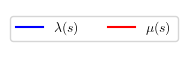

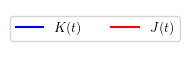

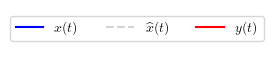

In [2]:
fig, ax = plt.subplots(figsize=(2, 0.5))

# Create empty lines with labels
ax.plot([], [], color="blue")
ax.plot([], [], color="red")
ax.axis('off')

# Create the legend
plt.legend(["$\lambda(s)$", "$\mu(s)$"], bbox_to_anchor=[0.5, 0.5], loc='center', fontsize=10, ncol=4)

plt.savefig('../figures/main_invert_distribution_legend.pdf', bbox_inches='tight', pad_inches=0.1)



fig, ax = plt.subplots(figsize=(2, 0.5))

# Create empty lines with labels
ax.plot([], [], color="blue")
ax.plot([], [], color="red")
ax.axis('off')

# Create the legend
plt.legend(["$K(t)$", "$J(t)$"], bbox_to_anchor=[0.5, 0.5], loc='center', fontsize=10, ncol=4)

plt.savefig('../figures/main_invert_kernel_legend.pdf', bbox_inches='tight', pad_inches=0.1)


fig, ax = plt.subplots(figsize=(2, 0.5))

# Create empty lines with labels
ax.plot([], [], color="blue")
ax.plot([], [], color="lightgray", linestyle="--")
ax.plot([], [], color="red")
ax.axis('off')

# Create the legend
plt.legend(["$x(t)$", "$\widehat{x}(t)$", "$y(t)$"], bbox_to_anchor=[0.5, 0.5], loc='center', fontsize=10, ncol=4)

plt.savefig('../figures/main_invert_data_legend.pdf', bbox_inches='tight', pad_inches=0.1)

In [3]:
# Define analytical spectral distribution lambda
density = lambda s: (s > 0) * (s < 1)
atoms = np.array([])
atom_wts = np.array([])
quad_pts, quad_wts = trap_quad(-1, 2, int(1e4))
lmbda = Distribution(density, atoms, atom_wts, quad_pts, quad_wts)

# Define noisy input trajectory x(t)
T = 10
t = np.linspace(0, T, 1000)
dt = t[1] - t[0]

n_interp = 20
np.random.seed(1)
interp_xs = np.cumsum(np.insert(np.random.randn(n_interp), 0, 0))/np.sqrt(n_interp)
interp_ts = np.linspace(0, T, n_interp+1)
cs = scipy.interpolate.make_interp_spline(interp_ts, interp_xs, k=5)
x = cs(t)

# Define Volterra equation kernel and coefficients
K = exp_kernel(lmbda, t)
c0 = 0
c1 = 0

# Compute output trajectory y(t) and corrupt it with noise
xdot = np.gradient(x, dt)
y = c1*xdot - c0*x - conv_trap(K, x, t)
ydot = np.gradient(y, dt)

# Use the spectral inversion map B to compute the inverse spectra mu and mu_hat from lambda and lambda_hat
mu_analytic, zeta0, zeta1 = B_real(lmbda, c0, c1)

# Compute the analytical inverse kernel J corresponding to K, and use it to reconstruct x
#J_spectral = exp_kernel(mu, t)

#alpha1 = 1/(1-np.exp(-1))
#beta1 = np.pi**2/(np.exp(1) + np.exp(-1) - 2)
#mu_density = lambda s: (s > 0) * (s < 1) / (1 + (s + np.log(np.abs(1-1/s)))**2/np.pi**2)
#mu_analytic = Distribution(mu_density, np.array([alpha1]), np.array([beta1]), quad_pts, quad_wts)
J_analytic = exp_kernel(mu_analytic, t)

x_analytic = (-1/math.pi**2) * (zeta1*ydot - zeta0*y - conv_trap(J_analytic, y, t))

#rel_err_J = np.linalg.norm(J_spectral - J_analytic) / np.linalg.norm(J_analytic)
rel_err_x = np.linalg.norm(x_analytic - x) / np.linalg.norm(x)

AAA failed to converge within 200 iterations.


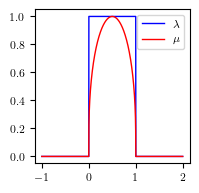

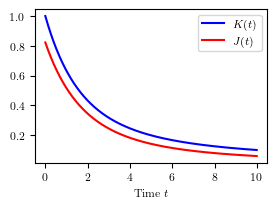

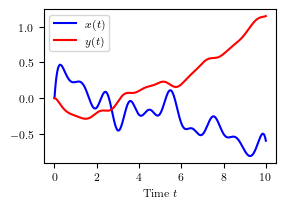

In [4]:
fig, ax = plt.subplots(figsize=(2, 2))
plot_real_distribution(ax, lmbda, color="blue", density_label=rf"$\lambda$")
plot_real_distribution(ax, mu_analytic, color="red", density_label=rf"$\mu$")
plt.legend()
plt.savefig(f"../figures/table_distribution_inversion.pdf", bbox_inches='tight', pad_inches=0.08)
plt.show()

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(t[t < 10], K[t < 10], color="blue")
ax.plot(t[t < 10], J_analytic[t < 10], color="red")
plt.legend([rf"$K(t)$", rf"$J(t)$"])
ax.set_xlabel("Time $t$")
plt.savefig(f"../figures/table_kernel_inversion.pdf", bbox_inches='tight', pad_inches=0.08)
plt.show()

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(t, x, color="blue", zorder=0)
ax.plot(t, y, color="red", zorder=1)
#ax.plot(t, x_analytic, linestyle='--', color="lightgray")
#ax.set_title(f"Rel. Err. = {rel_err_x:.3e}", size=10)
ax.set_xlabel("Time $t$")
plt.legend([rf"$x(t)$", rf"$y(t)$", rf"$x_{{spec}}(t)$"])
plt.savefig(f"../figures/table_data_inversion.pdf", bbox_inches='tight', pad_inches=0.08)
plt.show()

In [18]:
T = 10
Nt = int(1e1)
t = np.linspace(0, T, Nt)
dt = t[1] - t[0]

J_analytic = exp_kernel(mu_analytic, t)

K = exp_kernel(lmbda, t)

e1 = np.zeros(len(K))
e1[0] = 1
Kdisc = conv_fourier(K, e1, t)
Kmat = scipy.linalg.toeplitz(Kdisc, np.zeros(len(Kdisc)))

#J_disc = np.linalg.solve(Kmat, e1)
J_disc = scipy.linalg.solve_triangular(Kmat, e1, lower=True)

#J_num, zeta0_num, zeta1_num = volterra_cm_numerical_inversion(lmbda, c0, c1, t)

In [19]:
err_analytic = 0
err_disc = 0

time_analytic = 0
time_disc = 0

Ntrials = 1000

for i in range(Ntrials):
    n_interp = 20
    interp_xs = np.cumsum(np.insert(np.random.randn(n_interp), 0, 0))/np.sqrt(n_interp)
    interp_ts = np.linspace(0, T, n_interp+1)
    cs = scipy.interpolate.make_interp_spline(interp_ts, interp_xs, k=5)
    x = cs(t)
    
    xdot = np.gradient(x, dt)
    y = c1*xdot - c0*x - conv_trap(K, x, t)
    
    start_time = time.time()
    ydot = np.gradient(y, dt)
    x_analytic = (-1/math.pi**2) * (zeta1*ydot - zeta0*y - conv_trap(J_analytic, y, t))
    time_analytic += time.time() - start_time
    
    start_time = time.time()
    x_disc = -scipy.linalg.solve_triangular(Kmat, y, lower=True)
    time_disc += time.time() - start_time
    
    err_analytic += np.linalg.norm(x_analytic - x) / np.linalg.norm(x)
    err_disc += np.linalg.norm(x_disc - x) / np.linalg.norm(x)

err_analytic /= Ntrials
err_disc /= Ntrials

time_analytic /= Ntrials
time_disc /= Ntrials


In [20]:
print(f"Error analytic: {err_analytic:.2e}")
print(f"Error disc: {err_disc:.2e}")

print(f"Time analytic: {time_analytic*1000}")
print(f"Time disc: {time_disc*1000}")

Error analytic: 2.23e-01
Error disc: 3.29e-01
Time analytic: 0.09281468391418457
Time disc: 0.024495840072631836


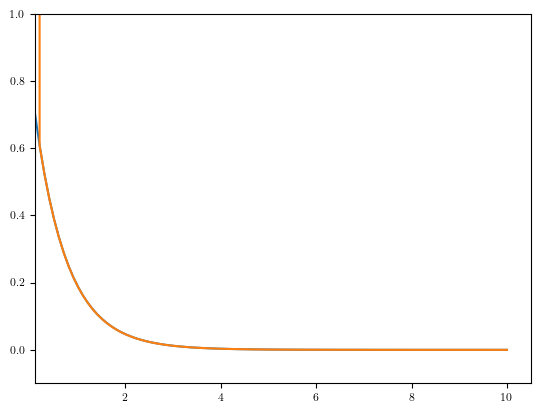

In [26]:
plt.plot(t, J_analytic)
#plt.plot(t, J_num)
plt.plot(t, -J_disc / dt * np.pi**2)
plt.xlim(0.1, None)
plt.ylim(-0.1, 1)
plt.show()

In [27]:
np.linalg.norm(J_analytic[2:] + (J_disc[2:] / dt * np.pi**2)) / np.linalg.norm(J_analytic[2:])

0.0016996754655793597

In [66]:
np.linalg.norm(J_analytic - J_numerical) / np.linalg.norm(J_analytic)

0.00745034665371814